# KPI Analysis – Delivery Performance

This notebook analyzes delivery performance, including actual delivery time, on-time versus late deliveries, delay duration, and delivery reliability.

In [5]:
import pandas as pd
import sys

print("Python:", sys.version)
print("Pandas:", pd.__version__)

Python: 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]
Pandas: 2.3.3


In [6]:
from pathlib import Path

data_path = Path("../data")

csv_files = list(data_path.glob("*.csv"))

for file in csv_files:
    print(file.name)

In [7]:
from pathlib import Path
print(Path.cwd())

c:\Users\user777\Desktop\Conclusion Intelegence project\SpikupCapstone2026_CYRV\notebooks


In [8]:
data_path = Path("../data")

print("Data folder exists:", data_path.exists())

for item in data_path.iterdir():
    print(item.name)

Data folder exists: True
cyrv
README.md


In [9]:
data_path = Path("../data/cyrv")

csv_files = list(data_path.glob("*.csv"))

for file in csv_files:
    print(file.name)

CYRV_customers_dataset.csv
CYRV_geolocation_dataset.csv
CYRV_orders_dataset.csv
CYRV_order_items_dataset.csv
CYRV_order_payments_dataset.csv
CYRV_order_reviews_dataset.csv
CYRV_products_dataset.csv
CYRV_sellers_dataset.csv
product_category_name_translation.csv


In [10]:
file_info = []

for file in csv_files:
    file_info.append({
        "file": file.name,
        "size_mb": round(file.stat().st_size / (1024 * 1024), 2)
    })

pd.DataFrame(file_info).sort_values("size_mb", ascending=False)

,file,size_mb
1,CYRV_geolocation_dataset.csv,59.39
2,CYRV_orders_dataset.csv,16.93
3,CYRV_order_items_dataset.csv,14.83
5,CYRV_order_reviews_dataset.csv,13.78
0,CYRV_customers_dataset.csv,8.71
4,CYRV_order_payments_dataset.csv,5.61
6,CYRV_products_dataset.csv,2.30
7,CYRV_sellers_dataset.csv,0.17
8,product_category_name_translation.csv,0.00


In [11]:
customers = pd.read_csv(data_path / "CYRV_customers_dataset.csv")
orders = pd.read_csv(data_path / "CYRV_orders_dataset.csv")
order_items = pd.read_csv(data_path / "CYRV_order_items_dataset.csv")
payments = pd.read_csv(data_path / "CYRV_order_payments_dataset.csv")
reviews = pd.read_csv(data_path / "CYRV_order_reviews_dataset.csv")
products = pd.read_csv(data_path / "CYRV_products_dataset.csv")
sellers = pd.read_csv(data_path / "CYRV_sellers_dataset.csv")
category_translation = pd.read_csv(
    data_path / "product_category_name_translation.csv"
)

print("Datasets loaded successfully ✅")

Datasets loaded successfully ✅


In [12]:
orders.dtypes

order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

In [13]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

orders[date_columns].dtypes

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [14]:
print("First order:", orders["order_purchase_timestamp"].min())
print("Last order:", orders["order_purchase_timestamp"].max())

First order: 2016-09-04 21:15:19
Last order: 2018-10-17 17:30:18


In [26]:

# Filter delivered orders
delivered_orders = orders[
    orders["order_status"] == "delivered"
].copy()

# Calculate actual delivery time in days
delivered_orders["actual_delivery_days"] = (
    delivered_orders["order_delivered_customer_date"]
    - delivered_orders["order_purchase_timestamp"]
).dt.total_seconds() / 86400

# Calculate delay in calendar days
delivered_orders["delay_days"] = (
    delivered_orders["order_delivered_customer_date"].dt.normalize()
    - delivered_orders["order_estimated_delivery_date"].dt.normalize()
).dt.days

# Define on-time delivery using calendar dates only
delivered_orders["on_time"] = (
    delivered_orders["order_delivered_customer_date"].dt.normalize()
    <= delivered_orders["order_estimated_delivery_date"].dt.normalize()
)

# Display delivery performance results
print("Delivered orders:", len(delivered_orders))

print(
    "Average actual delivery days:",
    round(delivered_orders["actual_delivery_days"].mean(), 2)
)

print(
    "On-time delivery rate:",
    round(delivered_orders["on_time"].mean() * 100, 2),
    "%"
)

print(
    "Late delivery rate:",
    round((~delivered_orders["on_time"]).mean() * 100, 2),
    "%"
)

print(
    "Late orders:",
    (~delivered_orders["on_time"]).sum()
)


Delivered orders: 96478
Average actual delivery days: 12.56
On-time delivery rate: 93.22 %
Late delivery rate: 6.78 %
Late orders: 6542


In [16]:
on_time_by_date = (
    delivered_orders["order_delivered_customer_date"].dt.normalize()
    <= delivered_orders["order_estimated_delivery_date"].dt.normalize()
)

print("New on-time rate:", round(on_time_by_date.mean() * 100, 2), "%")
print("New late rate:", round((~on_time_by_date).mean() * 100, 2), "%")
print("New late orders:", (~on_time_by_date).sum())
print("Orders reclassified:", (on_time_by_date & ~delivered_orders["on_time"]).sum())

New on-time rate: 93.22 %
New late rate: 6.78 %
New late orders: 6542
Orders reclassified: 1292


In [27]:
late_orders = delivered_orders[
    delivered_orders["on_time"] == False
].copy()

print("Late orders:", len(late_orders))

print(
    "Late delivery rate:",
    round(len(late_orders) / len(delivered_orders) * 100, 2),
    "%"
)

print(
    "Average delay days for late orders:",
    round(late_orders["delay_days"].mean(), 2)
)

print(
    "Maximum delay days:",
    round(late_orders["delay_days"].max(), 2)
)

Late orders: 6542
Late delivery rate: 6.78 %
Average delay days for late orders: 10.62
Maximum delay days: 188.0


In [28]:
late_orders["delay_days"].describe(
    percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
)

count    6534.000000
mean       10.620141
std        14.644955
min         1.000000
50%         7.000000
75%        13.000000
90%        22.000000
95%        31.000000
99%        71.340000
max       188.000000
Name: delay_days, dtype: float64

In [29]:
print("Late orders with missing delay_days:")
display(
    late_orders[
        late_orders["delay_days"].isna()
    ][[
        "order_id",
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]]
)

print("\nTop 10 longest delays:")
display(
    late_orders[
        ["order_id", "delay_days"]
    ]
    .sort_values("delay_days", ascending=False)
    .head(10)
)

Late orders with missing delay_days:


,order_id,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,2017-11-28 17:44:07,NaT,2017-12-18
20618,f5dd62b788049ad9fc0526e3ad11a097,2018-06-20 06:58:43,NaT,2018-07-16
43834,2ebdfc4f15f23b91474edf87475f108e,2018-07-01 17:05:11,NaT,2018-07-30
79263,e69f75a717d64fc5ecdfae42b2e8e086,2018-07-01 22:05:55,NaT,2018-07-30
82868,0d3268bad9b086af767785e3f0fc0133,2018-07-01 21:14:02,NaT,2018-07-24
92643,2d858f451373b04fb5c984a1cc2defaf,2017-05-25 23:22:43,NaT,2017-06-23
97647,ab7c89dc1bf4a1ead9d6ec1ec8968a84,2018-06-08 12:09:39,NaT,2018-06-26
98038,20edc82cf5400ce95e1afacc25798b31,2018-06-27 16:09:12,NaT,2018-07-19



Top 10 longest delays:


,order_id,delay_days
55619,1b3190b2dfa9d789e1f14c05b647a14a,188.0
19590,ca07593549f1816d26a572e06dc1eab6,181.0
11399,47b40429ed8cce3aee9199792275433f,175.0
81401,2fe324febf907e3ea3f2aa9650869fa5,167.0
89130,285ab9426d6982034523a855f55a885e,166.0
61610,440d0d17af552815d15a9e41abe49359,165.0
68769,c27815f7e3dd0b926b58552628481575,162.0
40847,d24e8541128cea179a11a65176e0a96f,161.0
38509,0f4519c5f1c541ddec9f21b3bddd533a,161.0
54480,2d7561026d542c8dbd8f0daeadf67a43,159.0


In [32]:
severe_delays = late_orders[late_orders["delay_days"] >= 30]

print("Orders delayed by 30 days or more:", len(severe_delays))

Orders delayed by 30 days or more: 360



## Initial Delivery Performance Findings

- Most delivered orders arrived on time (93.22%), while 6.78% were delivered after the estimated delivery date.
- Among late orders, the median delay was 7 days, and the average delay was 10.62 days.
- A small number of orders experienced very long delays, with the maximum delay reaching 188 days.
- 360 orders were delayed by 30 days or more.
- On-time delivery was evaluated using calendar dates rather than exact timestamps, following the agreed business definition.


In [33]:
delivery_status = delivered_orders["on_time"].value_counts()

on_time_count = delivery_status.get(True, 0)
late_count = delivery_status.get(False, 0)

total = on_time_count + late_count

delivery_summary = pd.DataFrame({
    "status": ["On-time", "Late"],
    "orders": [on_time_count, late_count],
    "percentage": [
        on_time_count / total * 100,
        late_count / total * 100
    ]
})

delivery_summary

,status,orders,percentage
0,On-time,89936,93.21918
1,Late,6542,6.78082


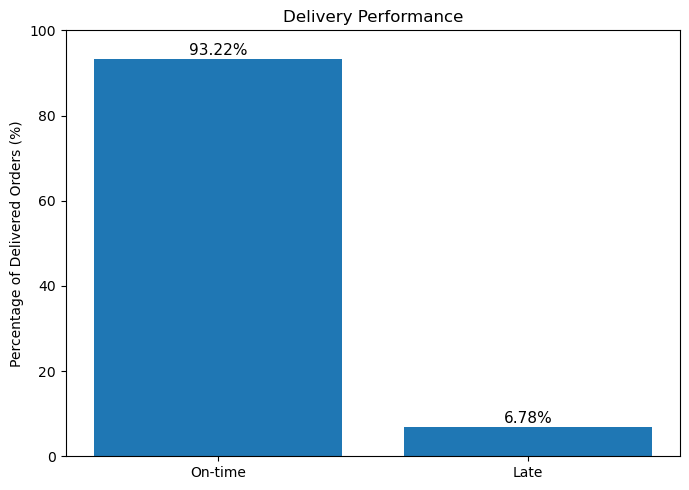

In [34]:
import matplotlib.pyplot as plt
# Delivery Performance: On-time vs Late

delivery_plot = delivery_summary.copy()
delivery_plot["percentage"] = delivery_plot["percentage"].round(2)

plt.figure(figsize=(7, 5))

bars = plt.bar(
    delivery_plot["status"],
    delivery_plot["percentage"]
)

plt.title("Delivery Performance")
plt.ylabel("Percentage of Delivered Orders (%)")
plt.ylim(0, 100)

# Add percentage labels
for bar, pct in zip(bars, delivery_plot["percentage"]):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f"{pct:.2f}%",
        ha="center",
        fontsize=11
    )

plt.tight_layout()
plt.show()


### Insight

- 93.22% of delivered orders arrived on time.
- 6.78% were delivered late.
- Delivery performance was evaluated using calendar dates rather than exact timestamps, following the agreed business definition.


In [35]:

# Delay severity among late deliveries

late_orders = delivered_orders[
    ~delivered_orders["on_time"]
].copy()

late_orders["delay_days"] = (
    late_orders["order_delivered_customer_date"].dt.normalize()
    - late_orders["order_estimated_delivery_date"].dt.normalize()
).dt.days

late_orders["delay_days"].describe()


count    6534.000000
mean       10.620141
std        14.644955
min         1.000000
25%         3.000000
50%         7.000000
75%        13.000000
max       188.000000
Name: delay_days, dtype: float64

In [40]:
# Late Delivery Severity

delay_severity = pd.cut(
    late_orders["delay_days"],
    bins=[0, 3, 7, 14, 30, float("inf")],
    labels=["1–3 days", "4–7 days", "8–14 days", "15–30 days", "30+ days"],
    include_lowest=True
)

severity_counts = delay_severity.value_counts().sort_index()

severity_counts

delay_days
1–3 days      1870
4–7 days      1802
8–14 days     1478
15–30 days    1039
30+ days       345
Name: count, dtype: int64

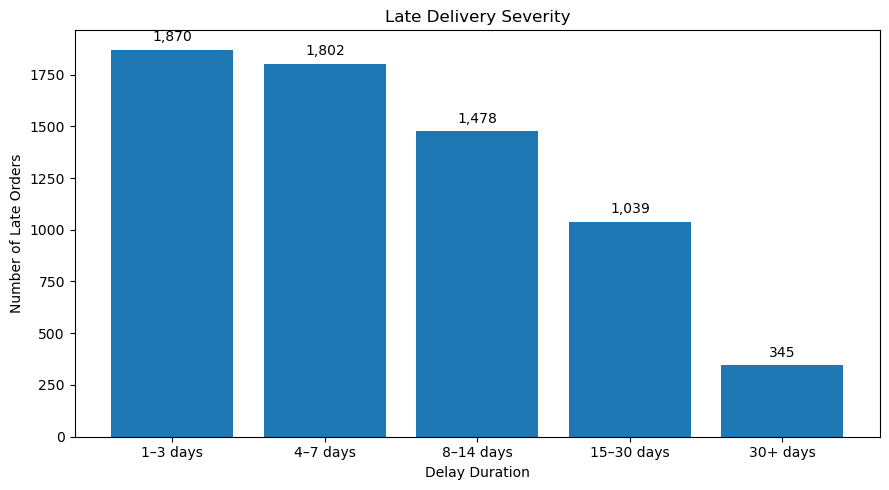

In [41]:
plt.figure(figsize=(9, 5))

bars = plt.bar(
    severity_counts.index.astype(str),
    severity_counts.values
)

plt.title("Late Delivery Severity")
plt.xlabel("Delay Duration")
plt.ylabel("Number of Late Orders")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 40,
        f"{int(bar.get_height()):,}",
        ha="center"
    )

plt.tight_layout()
plt.show()

### Insight

- Most late deliveries were delayed by 1–7 calendar days (3,672 orders).
- 1,478 orders were delayed by 8–14 days.
- 1,039 orders were delayed by 15–30 days.
- 345 orders experienced delays of more than 30 days.
- The median delay among late deliveries with valid delivery dates was 7 days, while the maximum delay reached 188 days.
- Delivery delays were calculated using calendar dates rather than exact timestamps, following the agreed business definition.

### Business Recommendations

- Focus on reducing severe delivery delays, especially orders delayed by 30+ days.
- Investigate sellers, routes, or logistics partners associated with repeated long delays.
- Set early-warning alerts for orders at risk of becoming significantly late.
- Track extreme delivery delays separately from normal delivery performance to identify operational issues quickly.